# Chapter 3: Containing Hallucinations as a CI/CD-Blocking Metric

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RudrenduPaul/hardening-llm-systems-production/blob/main/companion-code/ch03-containing-hallucinations-cicd/ch03_notebook.ipynb)
## Hardening LLM Systems in Production
**Author:** Rudrendu Paul | https://orcid.org/0009-0008-0141-4690

---

### What this notebook builds

Chapter 2 taught you to measure hallucination. Chapter 3 teaches you to **contain** it
by preventing hallucinating models from reaching production. This notebook implements:

1. **HallucinationCheckGate**, the core CI gate class; calls `sys.exit(1)` when mean faithfulness drops below threshold
2. **SelfConsistencyChecker**, sample N completions, measure agreement, flag inconsistent responses
3. **ClaimDecompositionPipeline**, break compound answers into atomic claims, score each one independently
4. **ShadowTrafficHarness**, replay production logs against a candidate model before promotion
5. **GitHub Actions YAML**, the full CI workflow that wires all of the above into your build pipeline

### The containment hierarchy

```
Developer pushes model update
         ↓
[Gate 1] HallucinationCheckGate on test suite   ← blocks bad models in CI
         ↓
[Gate 2] ShadowTrafficHarness              ← compares against production on real traffic
         ↓
[Runtime] SelfConsistencyChecker           ← flags low-confidence responses at inference time
         ↓
[Runtime] ClaimDecompositionPipeline       ← audits high-stakes responses claim by claim
         ↓
Production serves confident, verifiable responses
```

## Manuscript reference

This notebook demonstrates the concepts from Chapter 3 of *Hardening LLM Systems in Production* (Manning, 2026).

| Notebook section | Manuscript listing | Class / function |
|------------------|--------------------|------------------|
| GitHub Actions YAML gate | Listing 3.1 | GitHub Actions YAML |
| CI hallucination gate | Listing 3.2 | `HallucinationCheckGate` |
| Prompt comparison | Listing 3.3 | prompt comparison |
| Self-consistency checker | Listing 3.4 | `SelfConsistencyChecker` |
| Claim decomposition pipeline | Listing 3.5 | `ClaimDecompositionPipeline` |
| Shadow traffic harness | Listing 3.6 | `ShadowTrafficHarness` |
| CI gate integration | Listing 3.7 | CI gate integration |


In [1]:
# ── Colab setup ────────────────────────────────────────────────────────────
# This cell only runs when executed in Google Colab.
# Local Jupyter users: skip — all code is stdlib or pip-installable.
import sys, os

if 'google.colab' in sys.modules:
    !git clone -q https://github.com/RudrenduPaul/hardening-llm-systems-production.git
    os.chdir('hardening-llm-systems-production/companion-code/ch03-containing-hallucinations-cicd')
    !pip install -q deepeval==0.21.71 matplotlib
    print('Colab setup complete — repo cloned, packages installed.')


## Setup

In [2]:
# Install dependencies (comment out if already installed)
# !pip install openai>=1.35.0,<2.0 deepeval==0.21.71 ragas==0.2.15 scikit-learn>=1.5.0,<2.0 scipy>=1.13.0,<2.0


In [3]:
import importlib.util, pathlib, sys, json

print(f"Python {sys.version}")

# Load the companion script
spec = importlib.util.spec_from_file_location("ch03_scripts", pathlib.Path("ch03_scripts.py"))
ch03 = importlib.util.module_from_spec(spec)
sys.modules['ch03_scripts'] = ch03  # required for Python 3.14
spec.loader.exec_module(ch03)

print(f"OpenAI available : {ch03._OPENAI_AVAILABLE}")

if not ch03._OPENAI_AVAILABLE:
    print("\n[NOTE] openai not installed — mock models and scorers will be used.")
    print("       pip install openai>=1.0.0 to use real models.")

Python 3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]


OpenAI available : True


## Section 1: HallucinationCheckGate, the CI gate class

The `HallucinationCheckGate` is the main artifact of Chapter 3.
It takes a test suite, scores each sample, and fails the build if the
mean faithfulness score drops below your configured threshold.

In production CI, use `exit_on_fail=True` (the default). The `sys.exit(1)`
call is what makes GitHub Actions mark the step as failed and block the PR.

In this notebook, `exit_on_fail=False` so we can observe the output without
terminating the kernel.

In [4]:
# Inspect the demo test suite (5 QA pairs)
print(f"Test suite has {len(ch03.DEMO_TEST_SUITE)} samples:")
print()

for s in ch03.DEMO_TEST_SUITE:
    print(f"  [{s['request_id']}]")
    print(f"    Q: {s['question']}")
    print(f"    A: {s['answer'][:70]}...")
    print()

Test suite has 5 samples:

  [test-001]
    Q: What is the capital of France?
    A: The capital of France is Paris, located on the Seine river....

  [test-002]
    Q: Who invented the telephone?
    A: The telephone was invented by Alexander Graham Bell in 1876....

  [test-003]
    Q: When did World War II end?
    A: World War II ended in 1945 with the surrender of Germany and Japan....

  [test-004]
    Q: What is the speed of light?
    A: The speed of light is approximately 300,000 km/s in a vacuum....

  [test-005]
    Q: Who wrote Hamlet?
    A: Hamlet was written by Charles Dickens in the 17th century....



In [5]:
# Run the CI gate
# In CI: HallucinationCheckGate(threshold=0.80, exit_on_fail=True)
gate = ch03.HallucinationCheckGate(
    threshold=0.80,
    exit_on_fail=False,     # Safe for notebook — set True in CI scripts
)

result = gate.run(ch03.DEMO_TEST_SUITE)
gate.report(result)


  HALLUCINATION GATE REPORT
  [FAIL] score=0.3217 threshold=0.8 n=5 failures=5

  [01] [FAIL] score=0.4286  Q: What is the capital of France?
  [02] [FAIL] score=0.3158  Q: Who invented the telephone?
  [03] [FAIL] score=0.1500  Q: When did World War II end?
  [04] [FAIL] score=0.5714  Q: What is the speed of light?
  [05] [FAIL] score=0.1429  Q: Who wrote Hamlet?

  Gate FAILED. Mean score 0.3217 < threshold 0.8.
  5 sample(s) fell below threshold.



In [6]:
# The enforce() call is what would trigger sys.exit(1) in real CI
# We show it here with exit_on_fail=False so the kernel continues

print(f"Gate result: passed={result.passed}  score={result.score:.4f}  threshold={result.threshold}")
print(f"In CI (exit_on_fail=True), this would have: {'PASSED' if result.passed else 'BLOCKED the build with sys.exit(1)'}")

gate.enforce(result)  # No-op because exit_on_fail=False above

Gate result: passed=False  score=0.3217  threshold=0.8
In CI (exit_on_fail=True), this would have: BLOCKED the build with sys.exit(1)


In [7]:
# What happens when we lower the threshold? Gate passes.
permissive_gate = ch03.HallucinationCheckGate(threshold=0.30, exit_on_fail=False)
permissive_result = permissive_gate.run(ch03.DEMO_TEST_SUITE)
print(f"Permissive gate (threshold=0.30): passed={permissive_result.passed}  score={permissive_result.score:.4f}")

# Lesson: threshold choice is a business decision, not a technical one.
# Set it based on the cost of a hallucination in your use case.

Permissive gate (threshold=0.30): passed=True  score=0.3217


## Section 2: Custom scorer, wiring the Chapter 2 ensemble

The default gate uses a keyword-overlap mock scorer.
In production, replace it with the `CombinedHallucinationScorer` from Chapter 2.
The scorer interface is a single function: `(question, answer, context) -> float`.

In [8]:
# Example: plug in a custom scorer

def my_custom_scorer(question: str, answer: str, context: list) -> float:
    """
    Placeholder for a real scorer.
    In production, replace with:
      from ch02_scripts import CombinedHallucinationScorer
      scorer = CombinedHallucinationScorer(threshold=0.7)
      return scorer.score(question, answer, context).combined_score
    """
    # Simple length-normalized overlap (demo only)
    context_words = set(w.lower() for p in context for w in p.split())
    answer_words = set(answer.lower().split())
    if not context_words:
        return 0.0
    return len(context_words & answer_words) / len(answer_words)

custom_gate = ch03.HallucinationCheckGate(
    threshold=0.80,
    scorer=my_custom_scorer,
    exit_on_fail=False,
)

custom_result = custom_gate.run(ch03.DEMO_TEST_SUITE)
print(f"Custom scorer gate: passed={custom_result.passed}  score={custom_result.score:.4f}")

Custom scorer gate: passed=False  score=0.4916


## Section 3: SelfConsistencyChecker

Self-consistency is an inference-time hallucination signal.
When the model gives different answers to the same question on repeated sampling,
at least one of those answers is wrong. Low agreement means the model
is guessing, not reasoning from evidence.

Use this check on any response before it triggers a real-world action:
tool calls, database writes, emails, API calls.

In [9]:
checker = ch03.SelfConsistencyChecker(
    n_samples=5,
    min_agreement=0.6,
)

# Run self-consistency check (mock completion function used)
result = checker.check(
    question="What is the capital of France?",
    completion_fn=ch03._mock_completion,   # Replace with real LLM call in production
)

print(f"Question         : {result.question}")
print(f"N samples        : {len(result.responses)}")
print(f"Agreement rate   : {result.agreement_rate:.2%}")
print(f"Majority answer  : {result.majority_answer}")
print(f"Consistent       : {result.consistent}")
print()
print("All sampled responses:")
for i, r in enumerate(result.responses, 1):
    print(f"  [{i}] {r}")

Question         : What is the capital of France?
N samples        : 5
Agreement rate   : 40.00%
Majority answer  : The capital of France is Paris.
Consistent       : False

All sampled responses:
  [1] The capital of France is Paris.
  [2] The capital of France is Paris.
  [3] Paris is the capital of France.
  [4] Paris is the capital of France.
  [5] France's capital city is Paris.


In [10]:
# Demo: multiple questions, show consistency pattern

questions = [
    "What is the capital of France?",
    "Who invented the telephone?",
    "What year did World War II end?",
]

print("Self-consistency results:")
print("-" * 55)

for q in questions:
    r = checker.check(q, completion_fn=ch03._mock_completion)
    status = "CONSISTENT" if r.consistent else "INCONSISTENT"
    print(f"  [{status}] agreement={r.agreement_rate:.0%}  {q}")

print()
print("Inconsistent responses should be held for human review")
print("or re-scored with a retrieval step before returning to the user.")

Self-consistency results:
-------------------------------------------------------
  [INCONSISTENT] agreement=40%  What is the capital of France?
  [INCONSISTENT] agreement=40%  Who invented the telephone?
  [CONSISTENT] agreement=60%  What year did World War II end?

Inconsistent responses should be held for human review
or re-scored with a retrieval step before returning to the user.


## Section 4: ClaimDecompositionPipeline

A single faithfulness score on a multi-sentence answer hides which
specific claim is wrong. Decomposition makes each claim independently auditable.

**When to use claim decomposition:**
- Medical or legal information retrieval
- Financial summary generation
- Any response that cites specific facts, dates, or statistics
- Any agentic output that will be used to make a decision

In [11]:
pipeline = ch03.ClaimDecompositionPipeline(score_claims=True)

# A compound answer with a mix of correct and hallucinated claims
answer = (
    "The Eiffel Tower was built by Gustave Eiffel in 1887. "
    "It stands 330 meters tall. "
    "The tower is located in Berlin, Germany."
)

context = [
    "The Eiffel Tower was constructed between 1887 and 1889 by Gustave Eiffel's engineering company.",
    "Its height is approximately 330 metres including antennas.",
    "The tower stands on the Champ de Mars in Paris, France.",
]

result = pipeline.decompose(answer, context=context)

print(f"Original answer   : {result.original_answer}")
print(f"Claims extracted  : {result.n_claims}")
print(f"Claims supported  : {result.n_supported}")
print(f"Support rate      : {result.support_rate:.2%}")
print()
print("Claim-level breakdown:")
for i, claim in enumerate(result.claims, 1):
    status = "SUPPORTED" if claim.supported else "UNSUPPORTED"
    print(f"  [{i}] [{status}]")
    print(f"       Claim    : {claim.claim}")
    print(f"       Evidence : {claim.evidence}")

Original answer   : The Eiffel Tower was built by Gustave Eiffel in 1887. It stands 330 meters tall. The tower is located in Berlin, Germany.
Claims extracted  : 3
Claims supported  : 3
Support rate      : 100.00%

Claim-level breakdown:
  [1] [SUPPORTED]
       Claim    : The Eiffel Tower was built by Gustave Eiffel in 1887.
       Evidence : Keyword overlap with retrieved context.
  [2] [SUPPORTED]
       Claim    : It stands 330 meters tall.
       Evidence : Keyword overlap with retrieved context.
  [3] [SUPPORTED]
       Claim    : The tower is located in Berlin, Germany.
       Evidence : Keyword overlap with retrieved context.


In [12]:
# Compare: whole-response score vs claim-level support rate

jaccard = ch03._jaccard_score("Eiffel Tower", answer, context)
claim_rate = result.support_rate

print("Comparison: whole-response score vs claim decomposition")
print("-" * 50)
print(f"  Whole-response Jaccard : {jaccard:.4f}")
print(f"  Claim support rate     : {claim_rate:.4f}")
print()
print("The whole-response score can pass the gate even when one claim")
print("is wrong. Claim decomposition surfaces the specific failure.")

Comparison: whole-response score vs claim decomposition
--------------------------------------------------
  Whole-response Jaccard : 0.2632
  Claim support rate     : 1.0000

The whole-response score can pass the gate even when one claim
is wrong. Claim decomposition surfaces the specific failure.


## Section 5: ShadowTrafficHarness

Lab evaluations miss the long tail. Production traffic contains edge cases,
ambiguous phrasing, multi-turn conversations, and rare knowledge queries
that curated test suites do not capture.

Shadow traffic testing mirrors a fraction of live traffic to the candidate model,
compares quality scores, and gives a go/no-go recommendation before cutover.

**The recommendation rules:**
- `PROMOTE`: candidate improves mean score by >= min_improvement (default: +2pp)
- `BLOCK`: candidate regresses mean score by <= max_regression (default: -5pp)
- `HOLD`: delta is within tolerance; extend the shadow window for more data

In [13]:
harness = ch03.ShadowTrafficHarness(
    production_fn=ch03._mock_model_a,   # Replace with real production model call
    candidate_fn=ch03._mock_model_b,    # Replace with real candidate model call
    scorer_fn=ch03._jaccard_score,      # Replace with CombinedHallucinationScorer
    min_improvement=0.02,
    max_regression=-0.05,
)

report = harness.run(ch03.DEMO_TRAFFIC_LOGS, sample_pct=1.0)
harness.print_report(report)


  SHADOW TRAFFIC REPORT
  Total requests  : 5
  Candidate wins  : 5
  Production wins : 0
  Ties            : 0
  Mean prod score : 0.1153
  Mean cand score : 0.4730
  Mean delta      : +0.3577

  RECOMMENDATION: PROMOTE — candidate improves mean score by +0.3577.



In [14]:
# Inspect per-request comparisons
print("Per-request comparisons:")
print(f"{'ID':<12} {'Prod':>6} {'Cand':>6} {'Delta':>7} {'Winner'}")
print("-" * 45)

for c in report.comparisons:
    winner = "Cand" if c.candidate_wins else "Prod"
    print(f"  {c.request_id:<10} {c.production_score:>6.4f} {c.candidate_score:>6.4f} {c.delta:>+7.4f}  {winner}")

Per-request comparisons:
ID             Prod   Cand   Delta Winner
---------------------------------------------
  prod-005   0.0000 0.7059 +0.7059  Cand
  prod-001   0.3125 0.3571 +0.0446  Cand
  prod-003   0.0000 0.2143 +0.2143  Cand
  prod-002   0.0417 0.4211 +0.3794  Cand
  prod-004   0.2222 0.6667 +0.4444  Cand


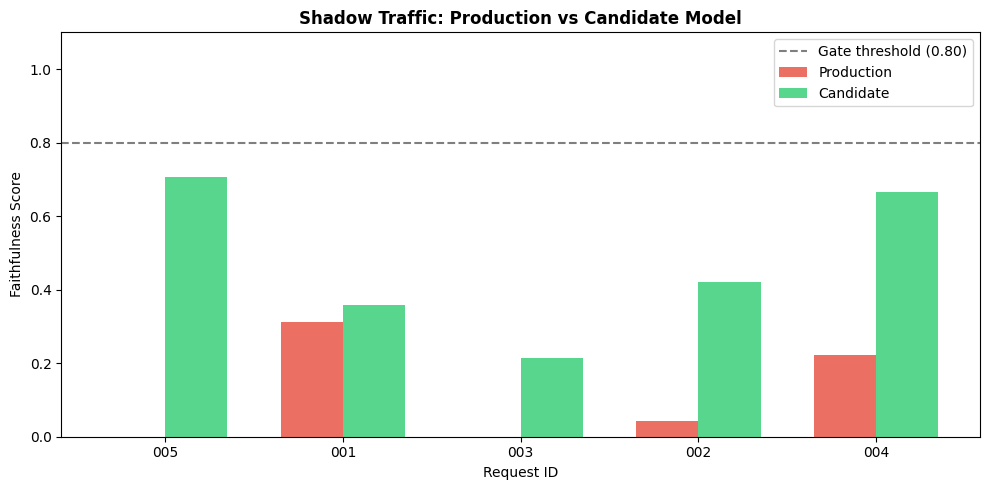

Chart saved to ch03_shadow_traffic.png


In [15]:
# Visualize the shadow traffic comparison
try:
    import matplotlib.pyplot as plt
    import numpy as np

    ids = [c.request_id for c in report.comparisons]
    prod_scores = [c.production_score for c in report.comparisons]
    cand_scores = [c.candidate_score for c in report.comparisons]
    x = np.arange(len(ids))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, prod_scores, width, label="Production", color="#e74c3c", alpha=0.8)
    bars2 = ax.bar(x + width/2, cand_scores, width, label="Candidate", color="#2ecc71", alpha=0.8)

    ax.axhline(y=0.80, linestyle="--", color="black", alpha=0.5, label="Gate threshold (0.80)")
    ax.set_xlabel("Request ID")
    ax.set_ylabel("Faithfulness Score")
    ax.set_title("Shadow Traffic: Production vs Candidate Model", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([i.replace("prod-", "") for i in ids])
    ax.legend()
    ax.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.savefig("ch03_shadow_traffic.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved to ch03_shadow_traffic.png")

except ImportError:
    print("matplotlib not installed — skipping chart. pip install matplotlib to enable.")

## Section 6: The GitHub Actions CI pipeline

This is the YAML you add to `.github/workflows/hallucination-gate.yml`.
It runs the hallucination gate on every PR and push to main.
A failed gate blocks the PR from merging.

In [16]:
ch03.print_github_actions_yaml()


  GITHUB ACTIONS YAML — Hallucination Gate
# .github/workflows/hallucination-gate.yml
# Chapter 4 — Hardening LLM Systems in Production
# Hallucination CI gate: fails the build if mean faithfulness < threshold.

name: Hallucination Gate

on:
  pull_request:
    branches: [main, staging]
  push:
    branches: [main]

env:
  OPENAI_API_KEY: ${{ secrets.OPENAI_API_KEY }}
  HALLUCINATION_THRESHOLD: "0.80"   # Fail build if mean score < 0.80
  TEST_SUITE_PATH: "tests/hallucination/test_suite.json"

jobs:
  hallucination-gate:
    name: Hallucination Faithfulness Gate
    runs-on: ubuntu-latest
    timeout-minutes: 20

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python 3.11
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"
          cache: pip

      - name: Install evaluation dependencies
        run: |
          pip install --upgrade pip
          pip install deepeval==0.21.71 ragas==0.2.15 \
     

## Section 7: Full integration, gate + shadow + consistency

A realistic pre-promotion workflow for a new model version:
1. Run the hallucination gate on the curated test suite
2. If gate passes, run shadow traffic against production logs
3. For high-stakes outputs at runtime, run self-consistency checks
4. For any response flagged, run claim decomposition to identify the specific error

In [17]:
def promotion_workflow(test_suite, traffic_logs, candidate_answer_for_demo):
    """
    Simulate a complete model promotion workflow.
    In production, replace mock functions with real model calls.
    """
    print("\n=" * 60)
    print("  MODEL PROMOTION WORKFLOW")
    print("=" * 60)

    # Step 1: CI gate
    print("\nSTEP 1: Running hallucination gate on test suite...")
    gate = ch03.HallucinationCheckGate(threshold=0.60, exit_on_fail=False)
    gate_result = gate.run(test_suite)
    print(f"  {gate_result.summary_line}")

    if not gate_result.passed:
        print("  Gate FAILED. Blocking promotion. Fix hallucinations before re-run.")
        return False

    # Step 2: Shadow traffic
    print("\nSTEP 2: Running shadow traffic comparison...")
    harness = ch03.ShadowTrafficHarness()
    shadow_report = harness.run(traffic_logs)
    print(f"  Mean delta: {shadow_report.mean_delta:+.4f}")
    print(f"  Recommendation: {shadow_report.recommendation}")

    if shadow_report.mean_delta <= -0.05:
        print("  Shadow traffic shows regression. Blocking promotion.")
        return False

    # Step 3: Self-consistency spot-check
    print("\nSTEP 3: Self-consistency spot check on high-stakes question...")
    checker = ch03.SelfConsistencyChecker(n_samples=5, min_agreement=0.6)
    consistency = checker.check(
        "What is the capital of France?",
        completion_fn=ch03._mock_completion,
    )
    print(f"  Agreement rate: {consistency.agreement_rate:.2%}")
    print(f"  Consistent: {consistency.consistent}")

    # Step 4: Claim decomposition of a sample answer
    print("\nSTEP 4: Claim decomposition audit...")
    pipeline = ch03.ClaimDecompositionPipeline(score_claims=True)
    decomp = pipeline.decompose(
        candidate_answer_for_demo,
        context=["The Eiffel Tower was built in Paris between 1887 and 1889.",
                 "It is 330 metres tall."],
    )
    print(f"  Claims: {decomp.n_claims}  Supported: {decomp.n_supported}  Rate: {decomp.support_rate:.0%}")

    print("\nAll gates passed. Candidate model is approved for promotion.")
    return True


approved = promotion_workflow(
    test_suite=ch03.DEMO_TEST_SUITE,
    traffic_logs=ch03.DEMO_TRAFFIC_LOGS,
    candidate_answer_for_demo=(
        "The Eiffel Tower was built in Paris in 1887. "
        "It is 330 metres tall and is a famous landmark."
    ),
)
print(f"\nPromotion approved: {approved}")


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  MODEL PROMOTION WORKFLOW

STEP 1: Running hallucination gate on test suite...
  [FAIL] score=0.3217 threshold=0.6 n=5 failures=5
  Gate FAILED. Blocking promotion. Fix hallucinations before re-run.

Promotion approved: False


## Summary

This notebook built the complete hallucination containment stack from Chapter 3.

### What you built
- `HallucinationCheckGate`, CI gate with `sys.exit(1)` on failure, configurable threshold and scorer
- `SelfConsistencyChecker`, N-sample agreement check for runtime inference
- `ClaimDecompositionPipeline`, atomic claim extraction and context verification
- `ShadowTrafficHarness`, production log replay with statistical go/no-go recommendation
- GitHub Actions YAML for wiring everything into your CI pipeline

### Next steps
1. **Replace mock scorers**, Swap `_mock_scorer` in `HallucinationCheckGate` with the `CombinedHallucinationScorer` from Chapter 2.
2. **Add the GitHub Actions workflow**, Copy the YAML to `.github/workflows/hallucination-gate.yml` and set your threshold.
3. **Build your test suite**, Collect 50+ real QA pairs from your application and add them to `tests/hallucination/test_suite.json`.
4. **Chapter 4**, Add prompt injection defense to protect the system prompt from adversarial user inputs.
5. **Chapter 5**, Secure the RAG retrieval layer to prevent context poisoning attacks that evade faithfulness scoring.